In [1]:
import xgboost

In [2]:
xgboost.__version__

'3.1.3'

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score)


import xgboost as xgb

## Load and Prepare Data

We load the dataset from `uci_bank_data.csv` and perform data cleaning and preprocessing

#### **Client-related attributes:**
- `age`: Age of the client (numeric)
- `job`: Type of job (categorical: e.g., admin., technician, unemployed)
- `marital`: Marital status (categorical: married, single, divorced)
- `education`: Education level (categorical: e.g., primary, secondary, tertiary)
- `default`: Has credit in default? (binary: yes/no)
- `balance`: Average yearly balance in euros (numeric)
- `housing`: Has housing loan? (binary: yes/no)
- `loan`: Has personal loan? (binary: yes/no)

#### **Campaign-related attributes:**
- `contact`: Contact communication type (categorical: cellular, telephone)
- `day`: Last contact day of the month (numeric)
- `month`: Last contact month (categorical)
- `duration`: Last contact duration in seconds (numeric)  
  **(Important: This feature is highly predictive but should be handled carefully in model building.)**

#### **Previous campaign attributes:**
- `campaign`: Number of contacts during this campaign (numeric)
- `pdays`: Days since last contact in a previous campaign (-1 means never contacted)
- `previous`: Number of contacts before this campaign (numeric)
- `poutcome`: Outcome of the previous campaign (categorical)

---

### **Output Variable**
- `y`: Has the client subscribed to a term deposit? (binary: yes/no)

In [6]:
df = pd.read_csv("../datasets/uci_bank_data.csv")

In [7]:
df.shape

(45211, 17)

In [8]:
df.isnull().sum()


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [9]:
df = df.drop(columns=["duration"])

In [10]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,4,-1,0,unknown,no


In [11]:
df["target"] = df.pop("y").map({"no": 0, "yes": 1})
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,-1,0,unknown,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,-1,0,unknown,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,-1,0,unknown,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,-1,0,unknown,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,-1,0,unknown,0


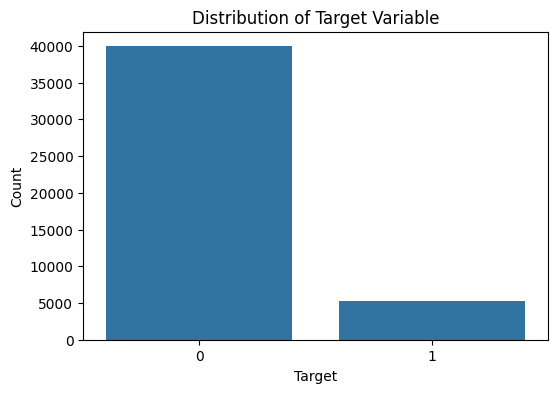

In [20]:
target_counts = df["target"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))

sns.barplot(x=target_counts.index, y=target_counts.values, ax=ax)

ax.set_xlabel("Target")
ax.set_ylabel("Count")
ax.set_title("Distribution of Target Variable")

plt.show()

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  campaign   45211 non-null  int64 
 12  pdays      45211 non-null  int64 
 13  previous   45211 non-null  int64 
 14  poutcome   45211 non-null  object
 15  target     45211 non-null  int64 
dtypes: int64(7), object(9)
memory usage: 5.5+ MB


In [23]:
categorial_variables = df.select_dtypes(exclude=np.number).columns.tolist()
categorial_variables

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome']

In [25]:
df[categorial_variables] = df[categorial_variables].astype("category")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        45211 non-null  int64   
 1   job        45211 non-null  category
 2   marital    45211 non-null  category
 3   education  45211 non-null  category
 4   default    45211 non-null  category
 5   balance    45211 non-null  int64   
 6   housing    45211 non-null  category
 7   loan       45211 non-null  category
 8   contact    45211 non-null  category
 9   day        45211 non-null  int64   
 10  month      45211 non-null  category
 11  campaign   45211 non-null  int64   
 12  pdays      45211 non-null  int64   
 13  previous   45211 non-null  int64   
 14  poutcome   45211 non-null  category
 15  target     45211 non-null  int64   
dtypes: category(9), int64(7)
memory usage: 2.8 MB


In [27]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42, stratify=y) #stratify, bo niezbalasowany

X_train.shape, X_test.shape

((31647, 15), (13564, 15))

In [29]:
xgb_clf = xgb.XGBClassifier(
    booster="gbtree",
    n_estimators=300,
    enable_categorical= True,
    objective="binary:logistic",
    tree_method="hist",
    eval_metric="auc",
    random_state=42
)

xgb_clf.fit(X_train, y_train)
y_pred = xgb_clf.predict(X_test)

In [30]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Evaluation Metrics:")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

Evaluation Metrics:
Accuracy: 0.8904
Precision: 0.5637
Recall: 0.2817
F1 Score: 0.3756


In [32]:
from collections import Counter

In [33]:
counts = Counter(y_train)
scale = counts[0]/ counts[1]
scale

7.548622366288493

In [34]:
scale = (y_train == 0).sum() / (y_train == 1).sum()
scale

np.float64(7.548622366288493)

In [35]:
xgb_clf = xgb.XGBClassifier(
    booster="gbtree",
    n_estimators=300,
    enable_categorical= True,
    objective="binary:logistic",
    tree_method="hist",
    eval_metric="auc",
    scale_pos_weight=scale,
    random_state=42
)

xgb_clf.fit(X_train, y_train)
y_pred = xgb_clf.predict(X_test)

In [36]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Evaluation Metrics:")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

Evaluation Metrics:
Accuracy: 0.8538
Precision: 0.3898
Recall: 0.4411
F1 Score: 0.4138


In [39]:
importances = xgb_clf.feature_importances_
features = X.columns

feature_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df

,Feature,Importance
14,poutcome,0.261771
8,contact,0.116258
6,housing,0.094421
10,month,0.084538
7,loan,0.050513
1,job,0.050151
2,marital,0.046065
9,day,0.044955
0,age,0.039353
4,default,0.037820


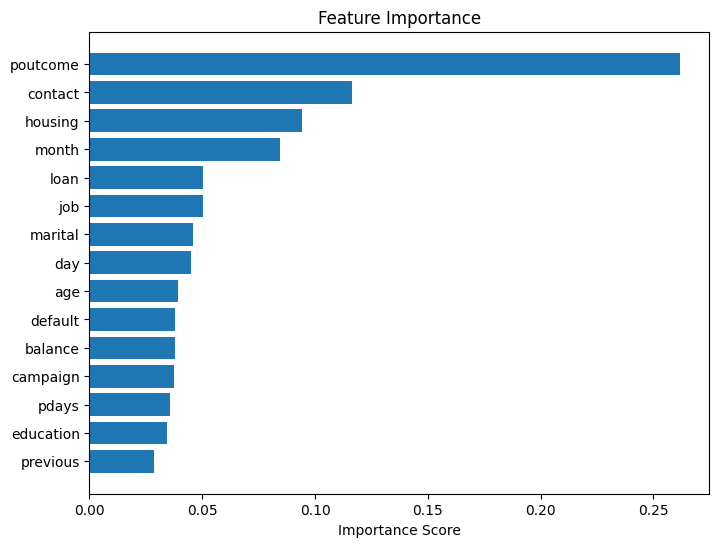

In [41]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

ax.set_xlabel("Importance Score")
ax.set_title("Feature Importance")


ax.invert_yaxis()

plt.show()

In [43]:
def train_evaluate_model(params):
    model = xgb_clf = xgb.XGBClassifier(
    booster="gbtree",
    n_estimators=300,
    enable_categorical= True,
    objective="binary:logistic",
    tree_method="hist",
    eval_metric="auc",
    scale_pos_weight=scale,
    random_state=42,
    **params
    )
    xgb_clf.fit(X_train, y_train)
    y_pred = xgb_clf.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    return accuracy, precision, recall, f1


In [46]:
params_list = [
    {"gamma": 0, "reg_lambda": 1, "reg_alfa": 0},
    {"gamma": 0.1, "reg_lambda": 2, "reg_alfa": 1},
    {"gamma": 0.3, "reg_lambda": 2, "reg_alfa": 0.5},

]

In [48]:
results = []

for params in params_list:
    acc, prec, rec, f1 = train_evaluate_model(params)
    results.append({
        "Parameters": params,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })

result_df = pd.DataFrame(results)
result_df

c:\Users\mateu\projects\data_science\ensamble_learning\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:56:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "reg_alfa" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\mateu\projects\data_science\ensamble_learning\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:56:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "reg_alfa" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\mateu\projects\data_science\ensamble_learning\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:56:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "reg_alfa" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Parameters,Accuracy,Precision,Recall,F1 Score
0,"{'gamma': 0, 'reg_lambda': 1, 'reg_alfa': 0}",0.853804,0.389755,0.441084,0.413834
1,"{'gamma': 0.1, 'reg_lambda': 2, 'reg_alfa': 1}",0.849823,0.380952,0.453686,0.414150
2,"{'gamma': 0.3, 'reg_lambda': 2, 'reg_alfa': 0.5}",0.838027,0.367851,0.534972,0.435944


### Early Stopping

In [50]:
X_train_es, X_val, y_train_es, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

X_train_es.shape, X_val.shape, X_test.shape

((25317, 15), (6330, 15), (13564, 15))

In [56]:
d_train = xgb.DMatrix(X_train_es, label=y_train_es, enable_categorical=True)
d_val = xgb.DMatrix(X_val, label=y_val, enable_categorical=True)
d_test = xgb.DMatrix(X_test, label=y_test, enable_categorical=True)

In [57]:
params = {
    'booster': 'gbtree',
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'tree_method': 'hist',
    'scale_pos_weight': scale,
    'random_state': 42
}

In [60]:
model = xgb.train(
    params,
    d_train,
    num_boost_round=1000,
    evals=[(d_val, "validation")],
    early_stopping_rounds=10,
    verbose_eval=True
)

[0]	validation-auc:0.75216
[1]	validation-auc:0.76933
[2]	validation-auc:0.77730
[3]	validation-auc:0.78746
[4]	validation-auc:0.78597
[5]	validation-auc:0.78864
[6]	validation-auc:0.78843
[7]	validation-auc:0.78542
[8]	validation-auc:0.78698
[9]	validation-auc:0.79032
[10]	validation-auc:0.78825
[11]	validation-auc:0.78734
[12]	validation-auc:0.78376
[13]	validation-auc:0.78311
[14]	validation-auc:0.78471
[15]	validation-auc:0.78354
[16]	validation-auc:0.78269
[17]	validation-auc:0.78272
[18]	validation-auc:0.78226
[19]	validation-auc:0.78348


In [63]:
y_pred_es = model.predict(d_test)
y_pred_es = [round(value) for value in y_pred_es]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Evaluation Metrics:")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

Evaluation Metrics:
Accuracy: 0.8538
Precision: 0.3898
Recall: 0.4411
F1 Score: 0.4138


### Cros validation

In [65]:
d_train = xgb.DMatrix(X_train, y_train, enable_categorical=True)
d_test = xgb.DMatrix(X_test, y_test, enable_categorical=True)

In [67]:
params = {
    'booster': 'gbtree',
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'tree_method': 'hist',
    'scale_pos_weight': scale,
    'random_state': 42
}

results =xgb.cv(
    params,
    d_train,
    nfold=5,
    num_boost_round=30
)

results

,train-auc-mean,train-auc-std,test-auc-mean,test-auc-std
0,0.772374,0.002845,0.748937,0.009550
1,0.789500,0.002613,0.764666,0.011221
2,0.801197,0.002813,0.777304,0.011722
3,0.809052,0.002907,0.783197,0.011822
4,0.815132,0.002268,0.786704,0.010074
5,0.820021,0.003775,0.786668,0.011605
6,0.826000,0.003313,0.788068,0.013267
7,0.830323,0.002872,0.789007,0.013311
8,0.835849,0.003705,0.790329,0.014152
9,0.842499,0.004145,0.790134,0.014104
